In [4]:
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as  plt
import seaborn as sns
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

In [5]:
# Data things from data/processed
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))
from src.data_processing.legacy import merged_dataset_legacy as merged_dataset

df = merged_dataset()
print(df.columns)
print(df.dtypes)

Index(['train', 'depart_station', 'arrive_station', 'minutes_late', 'DATE',
       'PRCP', 'SNOW', 'SNWD', 'TMAX', 'TMIN', 'PRCP_TOTAL', 'TAVG'],
      dtype='object')
train             string[python]
depart_station          category
arrive_station          category
minutes_late             float32
DATE              datetime64[ns]
PRCP                     float32
SNOW                     float32
SNWD                     float32
TMAX                     float32
TMIN                     float32
PRCP_TOTAL               float32
TAVG                     float32
dtype: object


In [3]:
def run_pipeline(df, keep_outliers=True, keep_mean_features=True, keep_old_years=True, use_time_features=False):
    df = df.copy()
    df["DATE"] = pd.to_datetime(df["DATE"])
    df = df.sort_values("DATE")
    df = df.dropna(subset=["minutes_late"]).reset_index(drop=True)
    
    # Optionally drop old years
    if not keep_old_years:
        df = df[df["DATE"].dt.year >= 2022].reset_index(drop=True)
    
    # Station pair feature
    df["station_pair"] = df["depart_station"].astype(str) + "→" + df["arrive_station"].astype(str)
    
    # Time features
    df["year"]  = df["DATE"].dt.year
    df["month"] = df["DATE"].dt.month
    df["day"]   = df["DATE"].dt.day
    df["dow"]   = df["DATE"].dt.dayofweek
    
    # Optionally transform target
    y = df["minutes_late"]
    if use_time_features:
        y = np.log1p(y)  # log(1 + x) to handle zeros
    
    # Optionally drop outliers
    if not keep_outliers:
        mean = y.mean()
        std = y.std()
        upper = mean + 3*std
        y = y.clip(upper=upper)
        df = df.loc[y.index].reset_index(drop=True)
    
    # Add cyclical encoding if using time features
    if use_time_features:
        # Cyclical encoding
        df["cos_month"] = np.cos(2 * np.pi * df["month"]/12)
        df["cos_day"]   = np.cos(2 * np.pi * df["day"]/31)
        df["cos_dow"]   = np.cos(2 * np.pi * df["dow"]/7)
        
        # Rolling delays
        df["rolling_delay3"] = df["minutes_late"].rolling(3, min_periods=1).mean()
        df["rolling_delay7"] = df["minutes_late"].rolling(7, min_periods=1).mean()
        df["total_prcp3"] = df["PRCP_TOTAL"].rolling(3, min_periods=1).sum()

    
    # Features
    X = df.drop(columns=["minutes_late"])
    
    # Train/test split: test = 2025
    X_train = X[X["DATE"].dt.year < 2025].copy()
    X_test  = X[X["DATE"].dt.year == 2025].copy()
    
    y_train = y.loc[X_train.index].copy()
    y_test  = y.loc[X_test.index].copy()
    
    dates_test = X_test["DATE"].reset_index(drop=True)
    
    # Drop DATE before training
    X_train.drop(columns=["DATE"], inplace=True)
    X_test.drop(columns=["DATE"], inplace=True)
    
    # Categorical mean encoding
    all_cat_cols = ["train", "depart_station", "arrive_station", "station_pair"]
    if keep_mean_features:
        for col in all_cat_cols:
            means = y_train.groupby(X_train[col], observed=True).mean()
            X_train[col + "_mean"] = X_train[col].map(means)
            X_test[col + "_mean"]  = X_test[col].map(means)

    X_train.drop(columns=all_cat_cols, inplace=True)
    X_test.drop(columns=all_cat_cols, inplace=True)
    
    # Fill unseen categories
    global_mean = y_train.mean()
    X_train.fillna(global_mean, inplace=True)
    X_test.fillna(global_mean, inplace=True)
    
    # Reset indices
    X_train = X_train.reset_index(drop=True)
    X_test  = X_test.reset_index(drop=True)
    y_train = y_train.reset_index(drop=True)
    y_test  = y_test.reset_index(drop=True)

    # Train models
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)
    pred_rf = rf_model.predict(X_test)
    
    xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100,
                                 learning_rate=0.1, max_depth=5, random_state=42)
    xgb_model.fit(X_train, y_train)
    pred_xgb = xgb_model.predict(X_test)

    # If log transform was used, convert back to minutes
    if use_time_features:
        y_test = np.expm1(y_test)
        pred_rf = np.expm1(pred_rf)
        pred_xgb = np.expm1(pred_xgb)
    
    # Metrics
    metrics = {}
    for name, y_pred in [("RF", pred_rf), ("XGB", pred_xgb)]:
        metrics[name] = {
            "MAE": mean_absolute_error(y_test, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "R2": r2_score(y_test, y_pred),
            "MAPE": mean_absolute_percentage_error(y_test, y_pred) * 100,
            "AvgActual": y_test.mean(),
            "AvgPred": y_pred.mean(),
            "CountPred6": (y_pred == 6).sum()
        }
    
    # Feature importances
    rf_importance = pd.DataFrame({"feature": X_train.columns, "importance": rf_model.feature_importances_}).sort_values("importance", ascending=False)
    xgb_importance = pd.DataFrame({"feature": X_train.columns, "importance": xgb_model.feature_importances_}).sort_values("importance", ascending=False)
    
    return {
        "metrics": metrics,
        "pred_rf": pred_rf,
        "pred_xgb": pred_xgb,
        "y_test": y_test,
        "dates_test": dates_test,
        "rf_importance": rf_importance,
        "xgb_importance": xgb_importance
    }

In [4]:
def plot_feature_importance(rf_importance, xgb_importance):
    # Plots
    fig, axes = plt.subplots(2, 1, figsize=(12, 18))

    sns.barplot(x="importance", y="feature", data=rf_importance, ax=axes[0])
    axes[0].set_title("Random Forest Importance")

    sns.barplot(x="importance", y="feature", data=xgb_importance, ax=axes[1])
    axes[1].set_title("XGBoost Feature Importance")

    plt.tight_layout()
    plt.show()

def plot_predictions_2025(dates_test, y_test, pred_rf, pred_xgb, title_suffix=""):
    """
    Plots actual vs predicted delays for Random Forest and XGBoost for the test year (2025).
    """
    # Reset indices
    dates_test = dates_test.reset_index(drop=True)
    y_test = y_test.reset_index(drop=True)
    pred_rf = pd.Series(pred_rf).reset_index(drop=True)
    pred_xgb = pd.Series(pred_xgb).reset_index(drop=True)

    # Focus on 2025 if dates_test contains more than 2025
    mask_2025 = dates_test.dt.year == 2025
    dates_2025 = dates_test[mask_2025]
    y_2025 = y_test[mask_2025]
    pred_rf_2025 = pred_rf[mask_2025]
    pred_xgb_2025 = pred_xgb[mask_2025]

    # Plot
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Random Forest
    axes[0].plot(dates_2025, y_2025, label="Actual", color="black")
    axes[0].plot(dates_2025, pred_rf_2025, label="Predicted", color="blue")
    axes[0].set_title(f"Random Forest: Actual vs Predicted {title_suffix}")
    axes[0].set_ylabel("Total Delay")
    axes[0].legend()

    # XGBoost
    axes[1].plot(dates_2025, y_2025, label="Actual", color="black")
    axes[1].plot(dates_2025, pred_xgb_2025, label="Predicted", color="green")
    axes[1].set_title(f"XGBoost: Actual vs Predicted {title_suffix}")
    axes[1].set_ylabel("Total Delay")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


Running Combo_1: keep_outliers=True, keep_mean_features=True, keep_old_years=True, use_time_features=True

Running Combo_2: keep_outliers=True, keep_mean_features=True, keep_old_years=True, use_time_features=False

Running Combo_3: keep_outliers=True, keep_mean_features=True, keep_old_years=False, use_time_features=True

Running Combo_4: keep_outliers=True, keep_mean_features=True, keep_old_years=False, use_time_features=False

Running Combo_5: keep_outliers=True, keep_mean_features=False, keep_old_years=True, use_time_features=True

Running Combo_6: keep_outliers=True, keep_mean_features=False, keep_old_years=True, use_time_features=False

Running Combo_7: keep_outliers=True, keep_mean_features=False, keep_old_years=False, use_time_features=True

Running Combo_8: keep_outliers=True, keep_mean_features=False, keep_old_years=False, use_time_features=False

Running Combo_9: keep_outliers=False, keep_mean_features=True, keep_old_years=True, use_time_features=True

Running Combo_10: keep_

,combo,model,MAE,RMSE,R2,MAPE,AvgActual,AvgPred,CountPred6
0,"Combo_1: keep_outliers=True, keep_mean_feature...",RF,3.853708,7.398676,0.377781,30.660925,11.450867,10.541195,0
1,"Combo_1: keep_outliers=True, keep_mean_feature...",XGB,3.809807,7.247765,0.402905,30.250442,11.450867,10.517769,0
2,"Combo_2: keep_outliers=True, keep_mean_feature...",RF,6.271318,9.992344,-0.134933,61.383126,11.450867,13.247737,44
3,"Combo_2: keep_outliers=True, keep_mean_feature...",XGB,5.389999,9.289427,0.019126,48.608640,11.450867,11.816989,0
4,"Combo_3: keep_outliers=True, keep_mean_feature...",RF,3.883116,7.430212,0.372465,30.734834,11.450867,10.539795,0
5,"Combo_3: keep_outliers=True, keep_mean_feature...",XGB,3.846251,7.370891,0.382445,30.283251,11.450867,10.503092,0
6,"Combo_4: keep_outliers=True, keep_mean_feature...",RF,6.027325,9.933106,-0.121516,57.175775,11.450867,12.763339,8
7,"Combo_4: keep_outliers=True, keep_mean_feature...",XGB,5.436762,9.412895,-0.007121,48.898923,11.450867,11.839602,0
8,"Combo_5: keep_outliers=True, keep_mean_feature...",RF,4.004900,7.709121,0.324469,32.266702,11.450867,10.530170,0
9,"Combo_5: keep_outliers=True, keep_mean_feature...",XGB,3.967514,7.732240,0.320412,31.413946,11.450867,10.399212,0



Best model for MAE:
combo         Combo_11: keep_outliers=False, keep_mean_featu...
model                                                       XGB
MAE                                                    3.526135
RMSE                                                   5.784738
R2                                                     0.354796
MAPE                                                  29.595754
AvgActual                                             11.105126
AvgPred                                               10.340515
CountPred6                                                    0
Name: 21, dtype: object


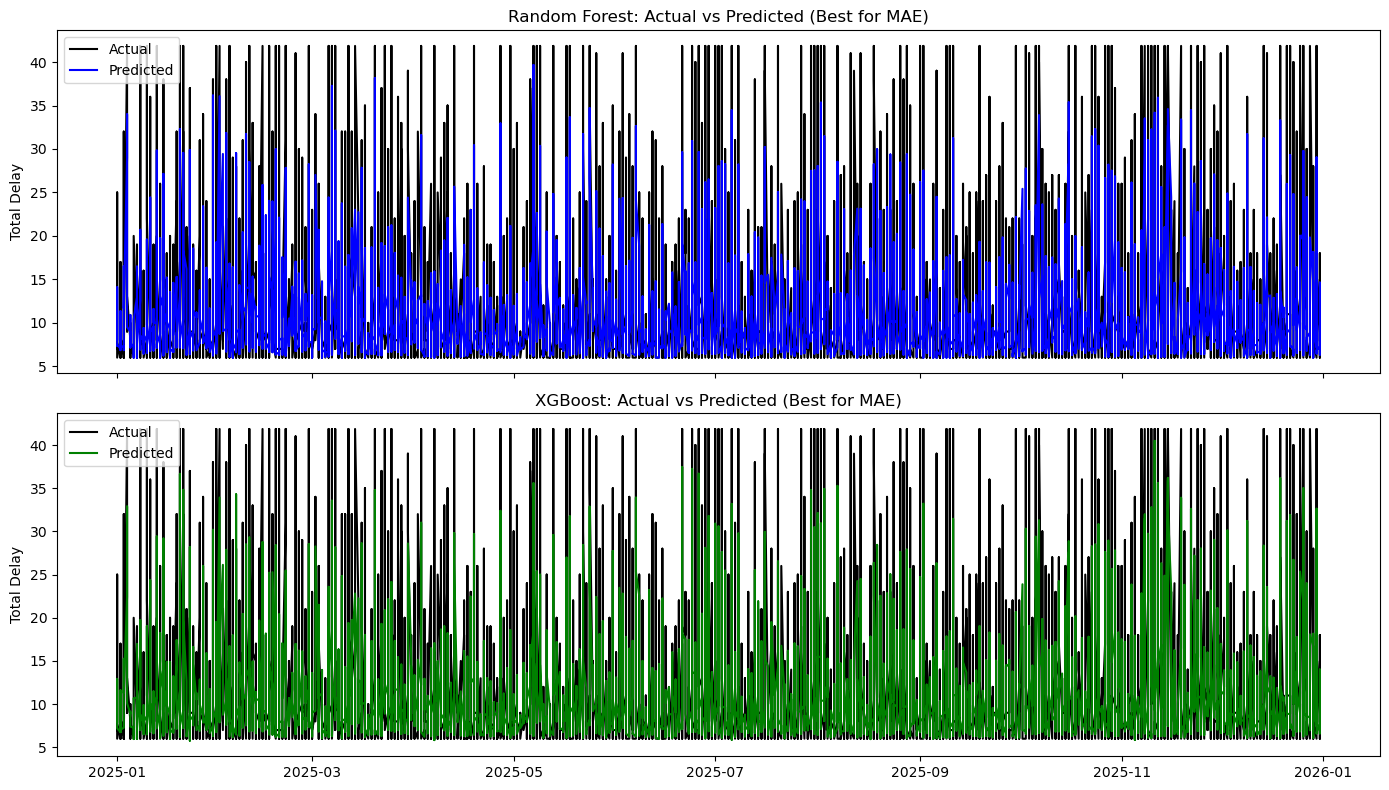


Best model for RMSE:
combo         Combo_11: keep_outliers=False, keep_mean_featu...
model                                                       XGB
MAE                                                    3.526135
RMSE                                                   5.784738
R2                                                     0.354796
MAPE                                                  29.595754
AvgActual                                             11.105126
AvgPred                                               10.340515
CountPred6                                                    0
Name: 21, dtype: object


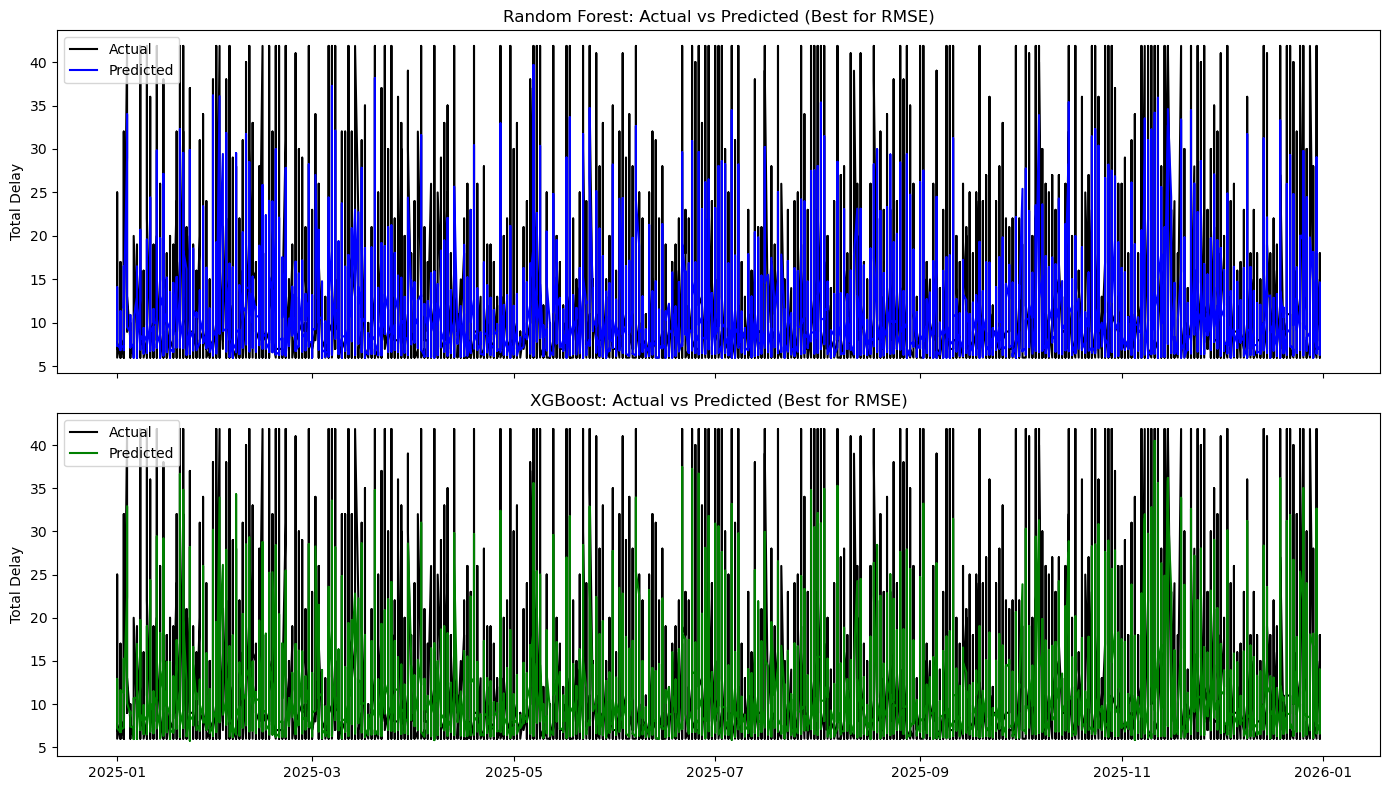


Best model for R2:
combo         Combo_1: keep_outliers=True, keep_mean_feature...
model                                                       XGB
MAE                                                    3.809807
RMSE                                                   7.247765
R2                                                     0.402905
MAPE                                                  30.250442
AvgActual                                             11.450867
AvgPred                                               10.517769
CountPred6                                                    0
Name: 1, dtype: object


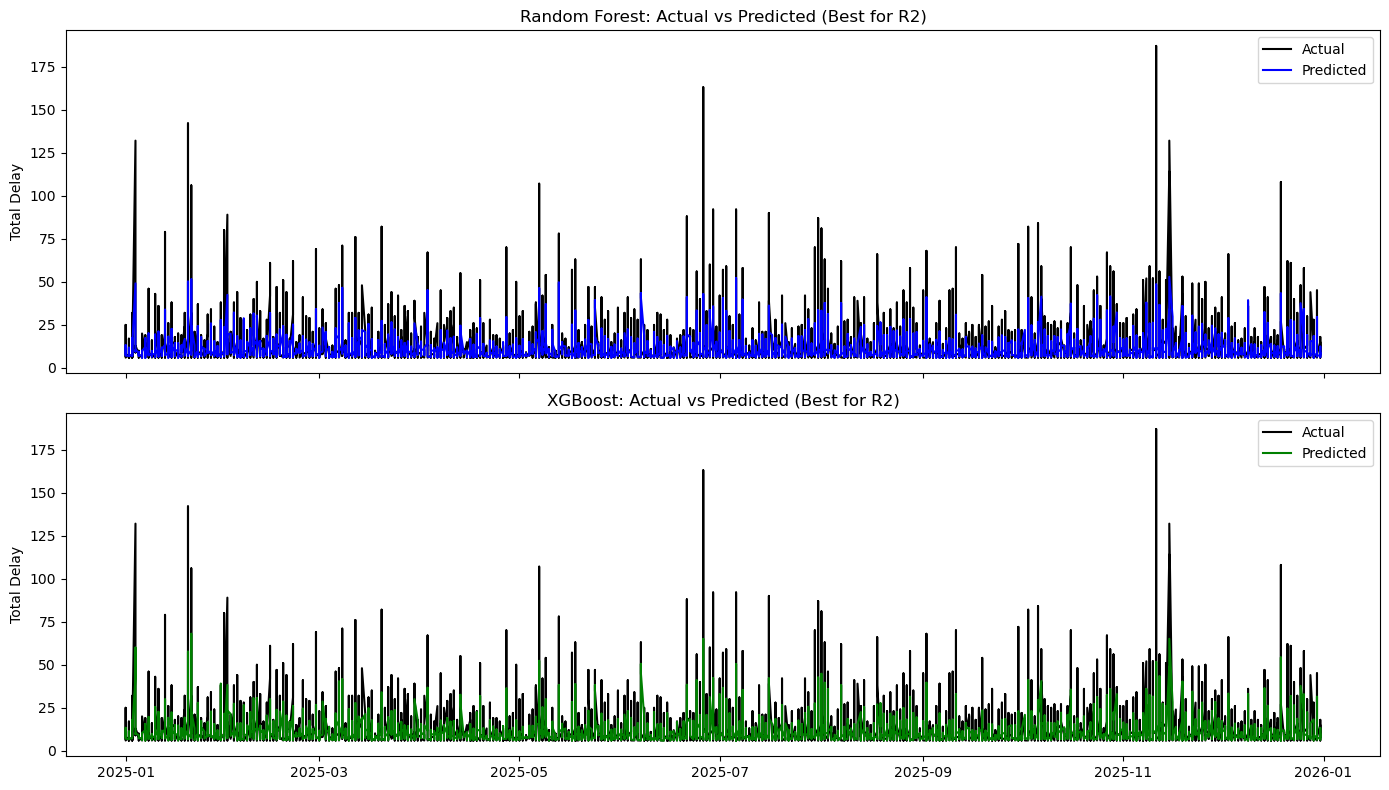


Best model for MAPE:
combo         Combo_11: keep_outliers=False, keep_mean_featu...
model                                                       XGB
MAE                                                    3.526135
RMSE                                                   5.784738
R2                                                     0.354796
MAPE                                                  29.595754
AvgActual                                             11.105126
AvgPred                                               10.340515
CountPred6                                                    0
Name: 21, dtype: object


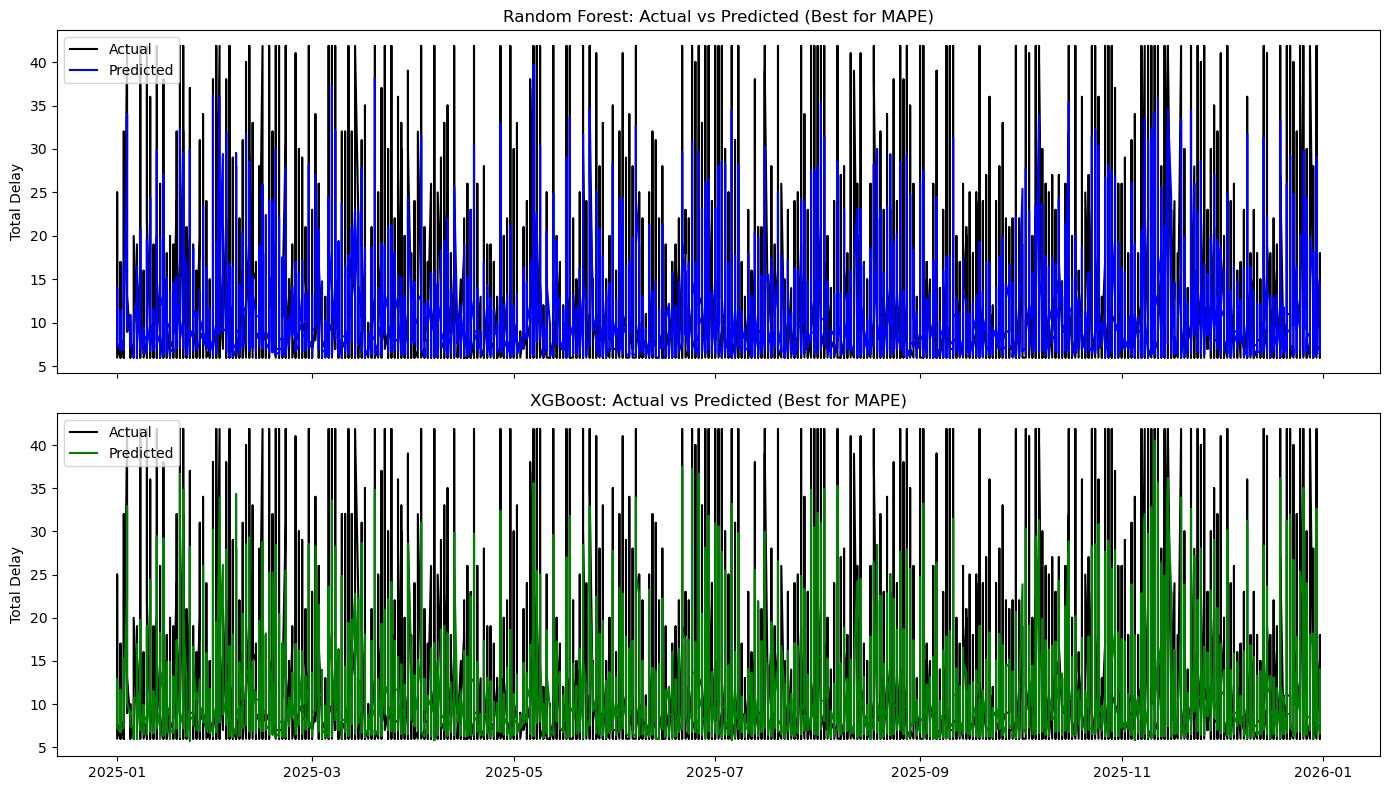


Best model for CountPred6:
combo         Combo_2: keep_outliers=True, keep_mean_feature...
model                                                        RF
MAE                                                    6.271318
RMSE                                                   9.992344
R2                                                    -0.134933
MAPE                                                  61.383126
AvgActual                                             11.450867
AvgPred                                               13.247737
CountPred6                                                   44
Name: 2, dtype: object


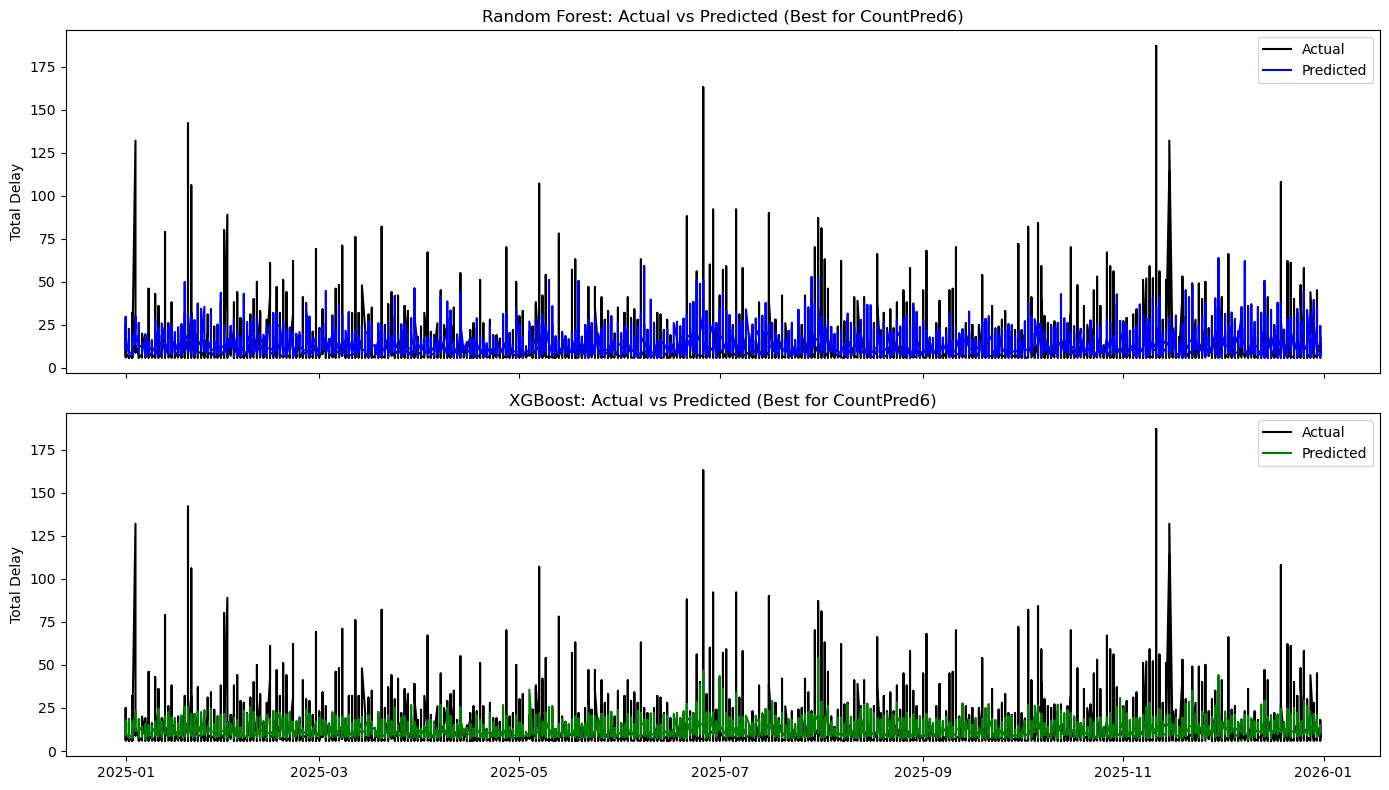

In [5]:
# Define ablation scenarios (This is for manual checking)
# ablations = [
#     {"name": "BASE", "keep_outliers" : True, "keep_mean_features": True, "keep_old_years": True, "use_time_features": False},
#     {"name": "DROP EXTREME OUTLIERS", "keep_outliers" : False, "keep_mean_features": True, "keep_old_years": True, "use_time_features": False},
#     {"name": "DROP MEAN FEATURE", "keep_outliers" : True, "keep_mean_features": False, "keep_old_years": False, "use_time_features": False},
#     {"name": "DROP PAST YEARS", "keep_outliers" : False, "keep_mean_features": False, "keep_old_years": False, "use_time_features": True}
# ]

# Define all flags
flag_options = {
    "keep_outliers": [True, False],
    "keep_mean_features": [True, False],
    "keep_old_years": [True, False],
    "use_time_features": [True, False]
}

# Generate all combinations
keys, values = zip(*flag_options.items())
all_combinations = [dict(zip(keys, v)) for v in product(*values)]

# Run all combinations and store metrics
records = []
all_results = {}
for i, combo in enumerate(all_combinations, 1):
    combo_name = f"Combo_{i}: " + ", ".join([f"{k}={v}" for k,v in combo.items()])
    print(f"\nRunning {combo_name}")
    
    res = run_pipeline(df, **combo)
    
    # Store full result object
    all_results[combo_name] = res
    
    # Store metrics
    for model_name, metric_dict in res["metrics"].items():
        record = {
            "combo": combo_name,
            "model": model_name,
            **metric_dict
        }
        records.append(record)

# Convert to DataFrame
df_results = pd.DataFrame(records)
display(df_results)

# Identify best model for each metric
best_models = {}
maximize_metrics = {"R2", "CountPred6"}
minimize_metrics = {"MAE", "RMSE", "MAPE"}
metrics_to_optimize = ["MAE", "RMSE", "R2", "MAPE", "CountPred6"]

for metric in metrics_to_optimize:
    if metric in maximize_metrics:
        best_idx = df_results[metric].idxmax()
    else:
        best_idx = df_results[metric].idxmin()
    
    best_models[metric] = df_results.loc[best_idx]

# Print and plot predictions for the best model of each metric
for metric, best_row in best_models.items():
    print(f"\nBest model for {metric}:")
    print(best_row)
    
    # Extract flag values from combo string
    flags = {
        "keep_outliers": "keep_outliers=True" in best_row["combo"],
        "keep_mean_features": "keep_mean_features=True" in best_row["combo"],
        "keep_old_years": "keep_old_years=True" in best_row["combo"],
        "use_time_features": "use_time_features=True" in best_row["combo"]
    }
    
    # Run pipeline again to get predictions for plotting
    res_best = run_pipeline(df, **flags)
    
    # Plot predictions for 2025
    plot_predictions_2025(
        dates_test=res_best["dates_test"],
        y_test=res_best["y_test"],
        pred_rf=res_best["pred_rf"],
        pred_xgb=res_best["pred_xgb"],
        title_suffix=f"(Best for {metric})"
    )

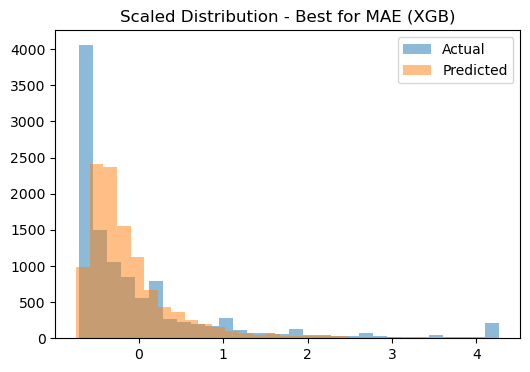

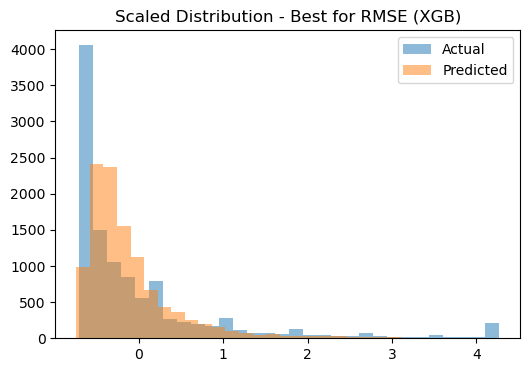

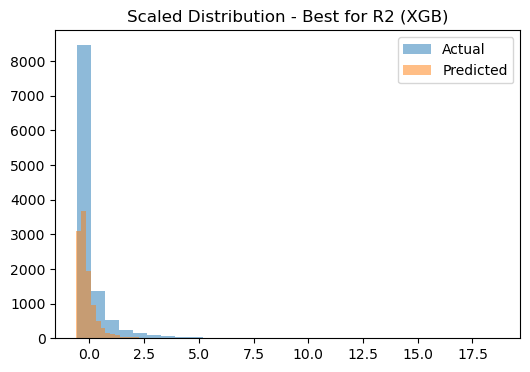

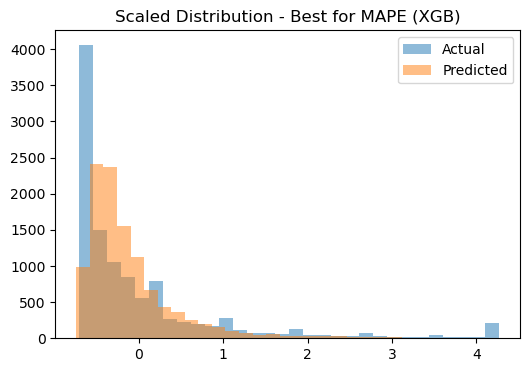

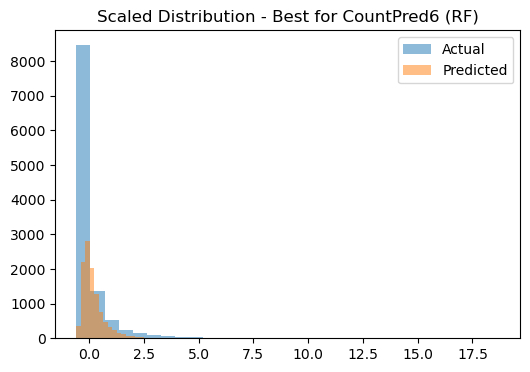

In [6]:
for metric, best_row in best_models.items():
    
    combo_name = best_row["combo"]
    model_name = best_row["model"]
    
    res_best = all_results[combo_name]
    
    y_test = res_best["y_test"]
    preds = res_best["pred_rf"] if model_name == "RF" else res_best["pred_xgb"]

    scaler = StandardScaler()

    y_scaled = scaler.fit_transform(y_test.values.reshape(-1,1))
    pred_scaled = scaler.transform(preds.reshape(-1,1))

    plt.figure(figsize=(6,4))
    plt.hist(y_scaled, bins=30, alpha=0.5, label="Actual")
    plt.hist(pred_scaled, bins=30, alpha=0.5, label="Predicted")
    plt.title(f"Scaled Distribution - Best for {metric} ({model_name})")
    plt.legend()
    plt.show()